In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spicy

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/penguins.csv")

In [8]:
rng = np.random.default_rng()

In [34]:
ndx = ~df["bill_length_mm"].isna()
N = np.sum(ndx)
x = df.loc[ndx, "bill_length_mm"]
R = 1_000
means = np.zeros(R)
for r in range(R):
    rx = rng.choice(x, size = N) # uniformly re-sampling our data N times
    means[r] = np.mean(rx)

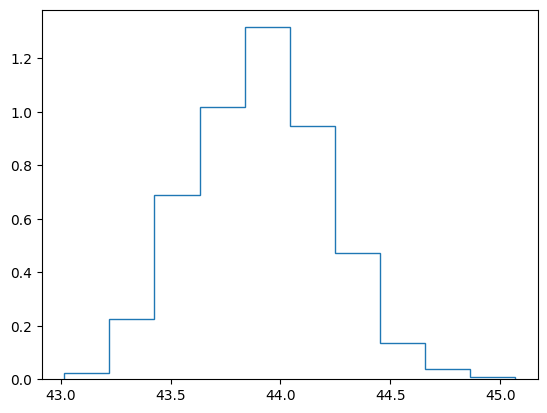

In [25]:
plt.hist(means, density = True, histtype = "step");

In [35]:
# bootstrap confidence interval
np.quantile(means, [0.025, 0.975])

array([43.32967836, 44.49831871])

In [33]:
# compared to the standard method
xbar = np.mean(df["bill_length_mm"])
s = np.std(df["bill_length_mm"])
N = np.sum(~df["bill_length_mm"].isna())
t = spicy.t(df = N - 1).ppf([0.025, 0.975]) # ppf(0.975)
xbar + t * s / np.sqrt(N)

array([43.34209692, 44.50176273])